# 02 — Preprocessing Validation (Phase 3)

## Objective
Visually and quantitatively verify the CT preprocessing pipeline (HU → window → resample → lung ROI → 2.5D patches) and that every step preserves the correspondence between image and nodule annotations.

## Configuration

In [1]:
import sys; sys.path.insert(0, '..')
from pathlib import Path
DATA = Path('../data'); FIG = Path('../results/figures')
CFG_PATH = '../configs/preprocessing.yaml'

## Imports

In [2]:
import json
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from src.utils.config import load_config
from src.preprocessing.io import load_ct
from src.preprocessing.pipeline import preprocess_scan
from src.preprocessing.patches import extract_25d_patch
plt.rcParams.update({'figure.dpi': 110})
cfg = load_config(CFG_PATH)
scans = pd.read_csv(DATA/'metadata/scans.csv'); ann = pd.read_csv(DATA/'metadata/annotations_voxel.csv')

## Example scans
One ordinary scan and one scan with flipped x/y axes, each with a nodule.

In [3]:
flip = scans[((scans.flip_x<0)|(scans.flip_y<0)) & (scans.n_nodules>0)].iloc[0]
norm = scans[((scans.flip_x>0)&(scans.flip_y>0)) & (scans.n_nodules>0)].iloc[3]
examples = {}
for name, s in [('normal', norm), ('flipped', flip)]:
    p = preprocess_scan(DATA, s.subset, s.seriesuid, cfg, keep_hu=True)
    a = ann[ann.seriesuid == s.seriesuid].sort_values('diameter_mm', ascending=False).iloc[0]
    examples[name] = (s, p, a)
    print(name, s.seriesuid[-10:], 'raw', (s.dim_x, s.dim_y, s.n_slices), (s.sp_x, s.sp_y, s.sp_z), '->', p.volume.shape_xyz, p.volume.spacing, '| nodule d =', round(a.diameter_mm,1), 'mm')

normal 7743874565 raw (np.int64(512), np.int64(512), np.int64(195)) (np.float64(0.72265625), np.float64(0.72265625), np.float64(1.7999999523162842)) -> (370, 370, 351) (np.float64(1.0), np.float64(1.0), np.float64(1.0)) | nodule d = 6.4 mm


flipped 4415322775 raw (np.int64(512), np.int64(512), np.int64(283)) (np.float64(0.7617189884185791), np.float64(0.7617189884185791), np.float64(1.25)) -> (390, 390, 354) (np.float64(1.0), np.float64(1.0), np.float64(1.0)) | nodule d = 18.5 mm


## 1. HU conversion and windowing
Raw values are already Hounsfield units; clipping removes scanner padding. The window [−1000, 400] HU maps to [0, 1] with fixed constants (no dataset statistics).

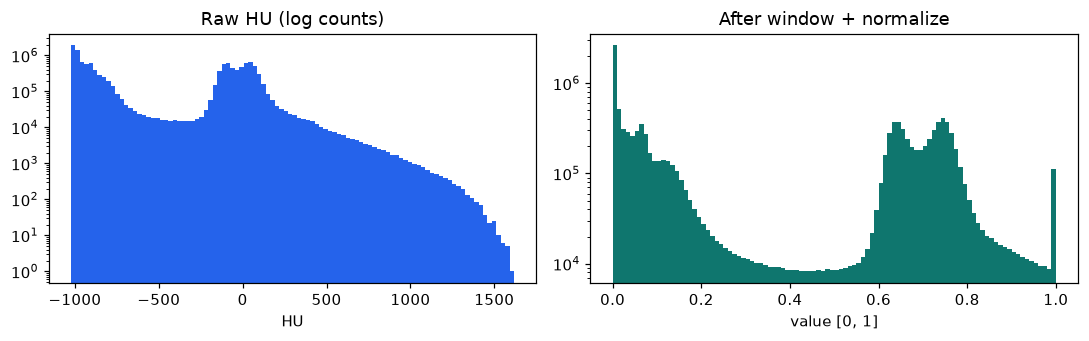

normalized range: 0.0 1.0 float32


In [4]:
s, p, a = examples['normal']
raw = load_ct(DATA, int(s.subset), s.seriesuid).array
fig, ax = plt.subplots(1, 2, figsize=(10, 3.2))
ax[0].hist(raw[::4].ravel(), bins=100, color='#2563EB', log=True); ax[0].set(title='Raw HU (log counts)', xlabel='HU')
ax[1].hist(p.volume.array[::4].ravel(), bins=100, color='#0F766E', log=True); ax[1].set(title='After window + normalize', xlabel='value [0, 1]')
plt.tight_layout(); plt.savefig(FIG/'exp000_preproc_hu_hist.png'); plt.show()
print('normalized range:', p.volume.array.min(), p.volume.array.max(), p.volume.array.dtype)

## 2. Coordinate alignment: annotation on raw vs preprocessed slice
The annotated world coordinate is mapped into the preprocessed grid (circle = annotated diameter). The flipped scan would be mis-located if its direction matrix were ignored.

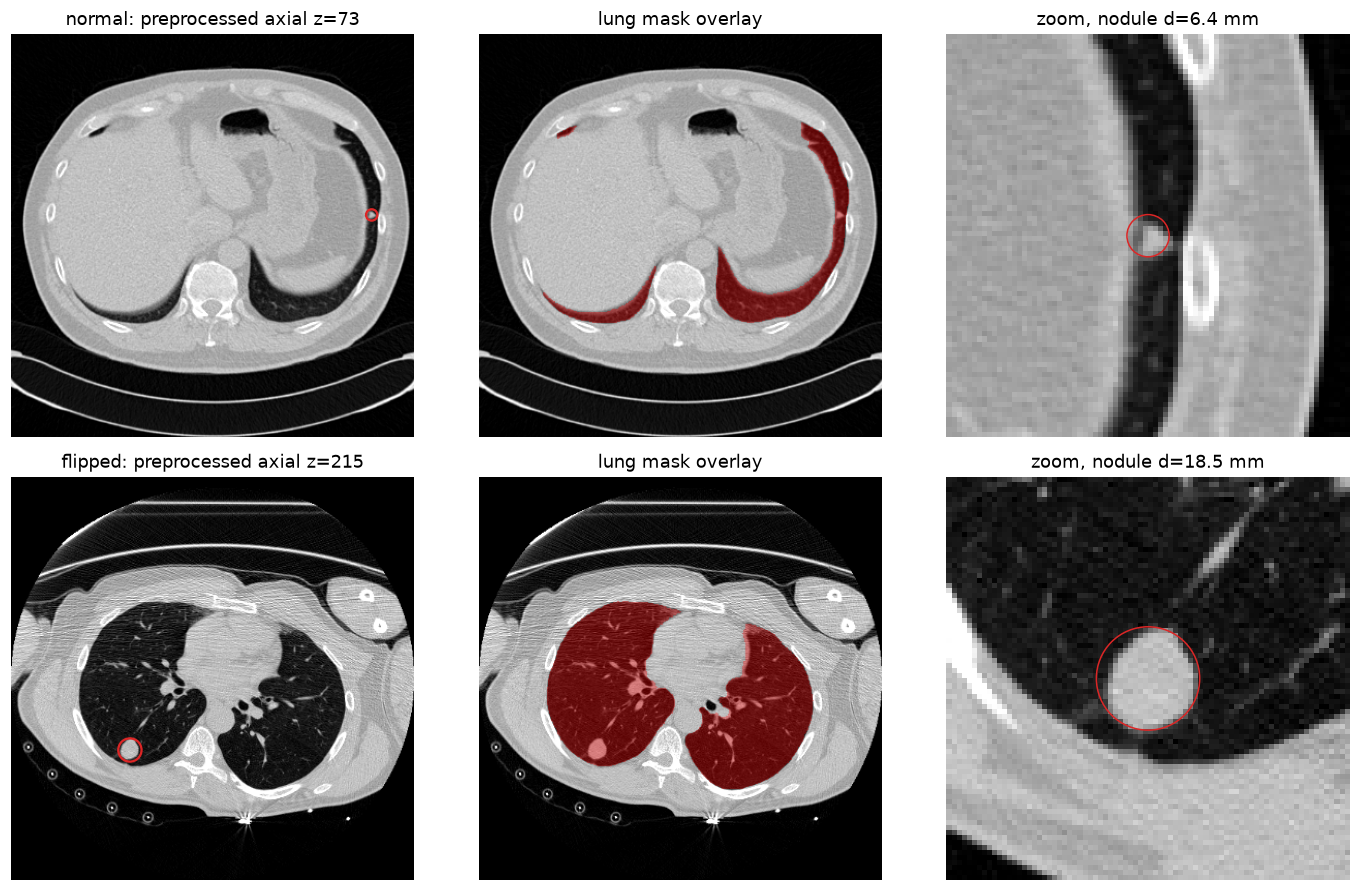

In [5]:
fig, axes = plt.subplots(2, 3, figsize=(13, 8.2))
for row, name in zip(axes, ['normal', 'flipped']):
    s, p, a = examples[name]
    w = np.array([a.coordX, a.coordY, a.coordZ]); v = p.volume.world_to_voxel(w); x, y, z = v
    zi = int(round(z)); r = a.diameter_mm / 2 / p.volume.spacing[0]
    row[0].imshow(p.volume.array[zi], cmap='gray', vmin=0, vmax=1); row[0].add_patch(plt.Circle((x, y), r+2, fill=False, color='#DC2626', lw=1.5)); row[0].set_title(f'{name}: preprocessed axial z={zi}')
    row[1].imshow(p.volume.array[zi], cmap='gray', vmin=0, vmax=1); row[1].imshow(np.ma.masked_where(~p.lung[zi], p.lung[zi]), cmap='autumn', alpha=.35); row[1].set_title('lung mask overlay')
    pad = 40; row[2].imshow(p.volume.array[zi, int(y)-pad:int(y)+pad, int(x)-pad:int(x)+pad], cmap='gray', vmin=0, vmax=1, extent=(-pad, pad, pad, -pad)); row[2].add_patch(plt.Circle((0, 0), r+1, fill=False, color='#DC2626')); row[2].set_title(f'zoom, nodule d={a.diameter_mm:.1f} mm')
    for q in row: q.axis('off')
plt.tight_layout(); plt.savefig(FIG/'exp000_preproc_alignment.png'); plt.show()

## 3. 2.5D patches (z−2 … z+2, 1 mm apart) at the nodule centre

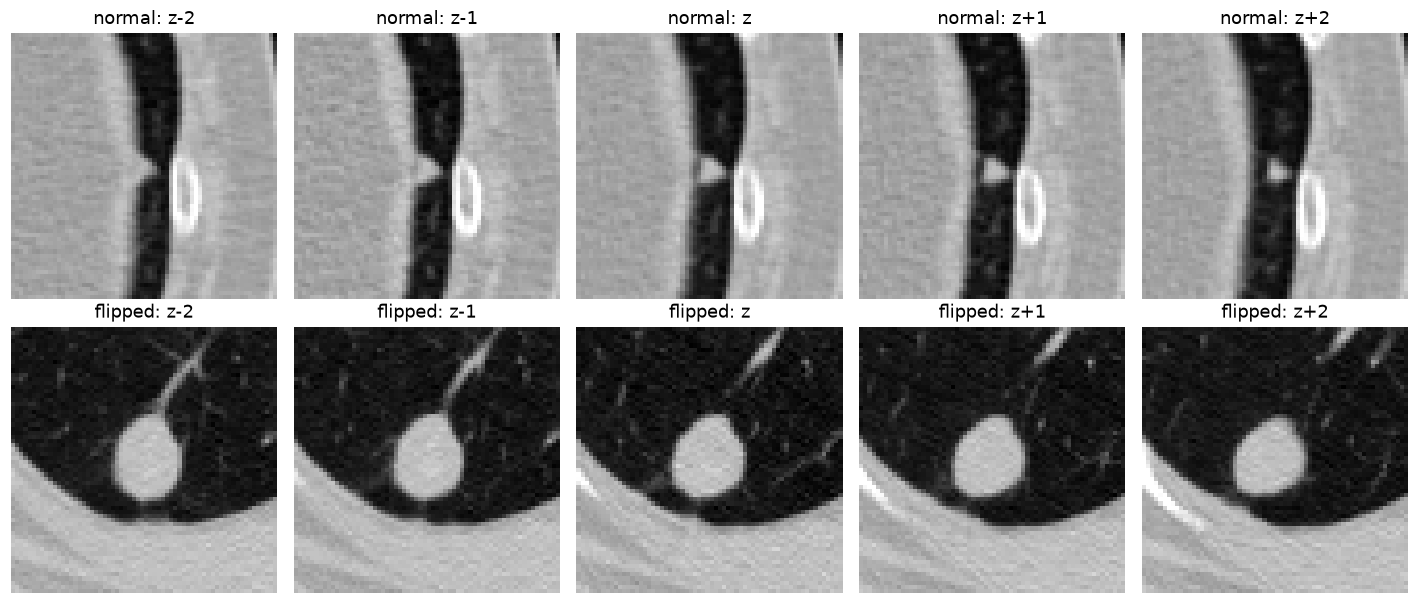

patch shape (C,H,W): (5, 64, 64)


In [6]:
n = cfg['slice_context']['input_slices']; h = n // 2
fig, axes = plt.subplots(2, n, figsize=(2.6*n, 5.6))
for row, name in zip(axes, ['normal', 'flipped']):
    s, p, a = examples[name]
    patch, c = extract_25d_patch(p.volume, [a.coordX, a.coordY, a.coordZ], size=cfg['patches']['size'], n_slices=n, stride=cfg['slice_context']['slice_stride'], pad_value=cfg['patches']['pad_value'])
    for k, q in enumerate(row):
        q.imshow(patch[k], cmap='gray', vmin=0, vmax=1); q.set_title(f'{name}: z{k-h:+d}' if k != h else f'{name}: z'); q.axis('off')
plt.tight_layout(); plt.savefig(FIG/'exp000_preproc_patches25d.png'); plt.show()
print('patch shape (C,H,W):', patch.shape)

The nodule stays centred in all five channels and neighbouring slices are in correct ascending-z order. Adjacent 1 mm slices look similar by design; whether wider context helps is decided by the Phase 5/6 slice-count/stride sweep.

## 4. Quantitative alignment check
Sampled 41 scans (all with nodules; every scan with flipped axes plus random others). `scripts/validate_preprocessing.py` measures mean intensity in a 1.5 mm sphere at each annotation, a random lung voxel (control), and, for flipped scans, the mirrored position (negative control).

,value
scans,41.000
annotations,79.000
flipped_scans,11.000
frac_aligned_dense(>-500HU),0.911
frac_random_lung_dense,0.038
frac_annotation_in_lung(5mm dilation),1.000
flipped_frac_aligned_dense,1.000
flipped_frac_mirrored_dense,0.583


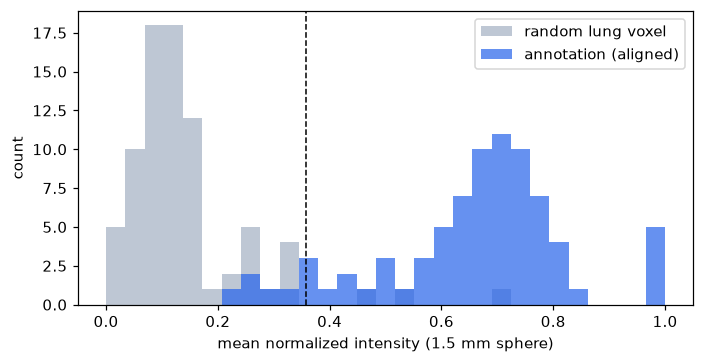

In [7]:
res = json.loads((DATA/'metadata/preprocessing_validation.json').read_text()); display(pd.Series(res).to_frame('value'))
al = pd.read_csv(DATA/'metadata/preprocessing_alignment.csv')
fig, ax = plt.subplots(figsize=(6.5, 3.4))
bins = np.linspace(0, 1, 30)
ax.hist(al.random_lung, bins, alpha=.6, label='random lung voxel', color='#94A3B8'); ax.hist(al.aligned, bins, alpha=.7, label='annotation (aligned)', color='#2563EB')
ax.axvline((-500+1000)/1400, color='k', ls='--', lw=1); ax.set(xlabel='mean normalized intensity (1.5 mm sphere)', ylabel='count'); ax.legend(); plt.tight_layout(); plt.savefig(FIG/'exp000_preproc_alignment_stats.png'); plt.show()

Annotations are dense (above −500 HU, dashed line) in ~91% of cases versus ~4% for random lung voxels; the remaining annotations are plausibly ground-glass nodules. On flipped scans, applying the direction correction gives 100% vs 58% at the mirrored position. All annotations fall inside the (5 mm-dilated) lung mask.

## 5. Candidate index

In [8]:
st = json.loads((DATA/'metadata/candidate_index_stats.json').read_text()); display(pd.DataFrame(st['per_split'])); print({k: v for k, v in st.items() if k != 'per_split'})

,split,candidates,positives,in_lung
0,test,75924,144,0.9988
1,train,604563,1218,0.9961
2,val,74488,195,0.9984


{'rows': 754975, 'positives_in_lung_frac': 0.9974, 'negatives_in_lung_frac': 0.9966, 'positives_outside_lung': 4}


## Conclusion
The pipeline turns a raw LUNA16 scan into a model-ready normalized, isotropically resampled volume with lung mask, 2.5D patches and a leakage-free candidate index, while preserving image–annotation correspondence. Phase 3 completion criteria met.